In [1]:
import pathlib

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import f_oneway, t

%matplotlib inline

In [2]:
repository_path = pathlib.Path.cwd().parents[2]
simulations_path = repository_path / "data" / "simulations"

In [3]:
simulation_games_data = pd.read_csv(simulations_path / "games.csv")
simulation_characters_data = pd.read_csv(simulations_path / "game_characters.csv")

# Hypothesis 3 - Character dominance in personal scoring

## 3.1 Question and pre-registered test

**Question.** Does any single character earn systematically more personal points than the others?

- **$H_0$:** the six characters have equal expected per-player final score.
- **$H_1$:** at least one character's expected per-player final score differs from the others.

**Scope.** The test is run on **6-player games only**. Six-player games are the only configuration where every character appears exactly once - at 7 and 8 players the rules duplicate non-Craftsman roles to fill the extra seats, and Hypothesis 2 already showed that *which* role is duplicated shifts the team win rate. The same duplication contaminates personal scoring: a "Builder score" sampled from an 8-player game where two Builders compete for the same wood-discount missions is not comparable to a Builder score from a 6-player game where Builder is the only one. Restricting to 6-player games isolates the intrinsic character effect.

**Test.** One-way ANOVA on `final_score` with `character` as the factor. With 4,000 6-player games and 6 characters per game, each character contributes 4,000 observations - well past the regime where the central limit theorem makes the F-test's normality assumption irrelevant. 95% confidence intervals are reported for each character's mean score. Significance level $\alpha = 0.05$.

## 3.2 Data preparation

Filter `games.csv` to the 6-player rows and join `game_characters.csv` to attach each game's per-character final scores. With 4,000 6-player games and 6 characters per game, the resulting dataframe has 24,000 rows.

In [4]:
six_player_games = simulation_games_data[simulation_games_data["player_count"] == 6]
six_player_scores = (
    six_player_games
    .merge(simulation_characters_data, on = "game_id")
    [["character", "final_score"]]
)

print(f"6-player score observations: {len(six_player_scores)}")
six_player_scores.head()

6-player score observations: 24000


,character,final_score
0,CRAFTSMAN,13
1,GATHERER,17
2,SAILOR,9
3,COOK,12
4,BUILDER,7


## 3.3 Per-character mean and 95% confidence interval

For each character, compute the mean final score and a 95% CI on the mean using the Student t-distribution (`mean ± t_{0.975, n-1} * SE`). With 4,000 observations per character the t-distribution is essentially normal here, but using `t.ppf` keeps the same code valid if the dataset shrinks.

In [5]:
character_stats = []
for character_name, group in six_player_scores.groupby("character"):
    scores = group["final_score"].values
    sample_size = len(scores)
    mean_score = scores.mean()
    standard_error = scores.std(ddof = 1) / np.sqrt(sample_size)
    margin = t.ppf(0.975, df = sample_size - 1) * standard_error
    character_stats.append({
        "character": character_name,
        "n": sample_size,
        "mean": mean_score,
        "ci_lower": mean_score - margin,
        "ci_upper": mean_score + margin,
    })

character_summary = (
    pd.DataFrame(character_stats)
    .set_index("character")
    .sort_values("mean", ascending = False)
)

overall_mean = six_player_scores["final_score"].mean()

print(f"Overall mean final score: {overall_mean:.4f}")
character_summary

Overall mean final score: 6.1562


,n,mean,ci_lower,ci_upper
character,,,,
COOK,4000,6.54625,6.434272,6.658228
FIRE_STARTER,4000,6.42275,6.318465,6.527035
CRAFTSMAN,4000,6.15925,6.058596,6.259904
BUILDER,4000,6.03450,5.932306,6.136694
GATHERER,4000,5.91800,5.815129,6.020871
SAILOR,4000,5.85625,5.756362,5.956138


**Chart.** Mean final score per character with 95% CI, sorted highest to lowest. The dashed line marks the overall mean across all 24,000 observations. A character bar whose CI does not cross the dashed line sits significantly above or below the average at the 5% level.

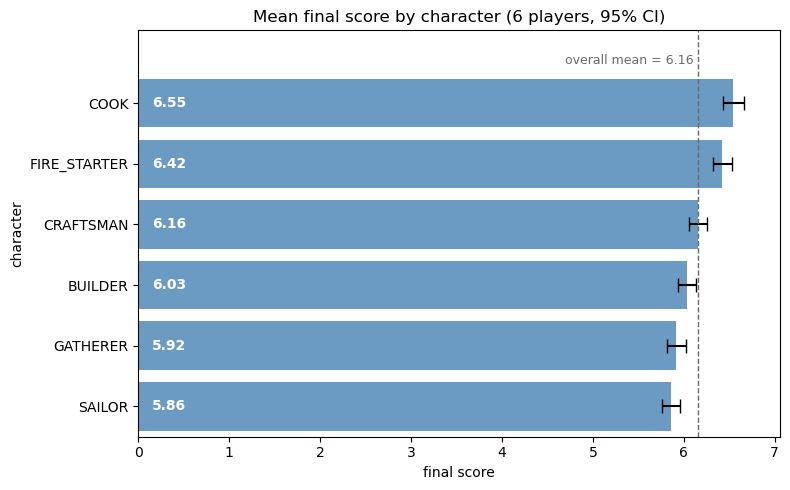

In [6]:
positions = np.arange(len(character_summary))
errors_lower = character_summary["mean"].values - character_summary["ci_lower"].values
errors_upper = character_summary["ci_upper"].values - character_summary["mean"].values

plt.figure(figsize = (8, 5))

plt.barh(positions, character_summary["mean"].values, color = "steelblue", alpha = 0.8)

plt.errorbar(character_summary["mean"].values, positions, xerr = [errors_lower, errors_upper],
             fmt = "none", color = "black", capsize = 5)

plt.axvline(overall_mean, color = "dimgray", linestyle = "--", linewidth = 1)
plt.text(overall_mean - 0.05, -0.7, f"overall mean = {overall_mean:.2f}",
         va = "center", ha = "right", fontsize = 9, color = "dimgray")

plt.yticks(positions, character_summary.index)
plt.xlabel("final score")
plt.ylabel("character")
plt.xlim(0, character_summary["ci_upper"].max() + 0.4)
plt.ylim(-1.2, len(character_summary) - 0.5)
plt.title("Mean final score by character (6 players, 95% CI)")

for i, mean_value in enumerate(character_summary["mean"].values):
    plt.text(0.15, i, f"{mean_value:.2f}", va = "center", ha = "left",
             color = "white", fontweight = "bold", fontsize = 10)
plt.gca().invert_yaxis()
plt.tight_layout()

plt.show()

## 3.4 One-way ANOVA across characters

ANOVA tests whether the six per-character mean scores all come from the same underlying distribution. With 4,000 observations per character (24,000 total), the central limit theorem makes the normality assumption of the F-test irrelevant, so the one-way F-test is the right primary test.

In [7]:
final_score_by_character = [
    six_player_scores.loc[six_player_scores["character"] == character_name, "final_score"].values
    for character_name in sorted(six_player_scores["character"].unique())
]

f_statistic, anova_p_value = f_oneway(*final_score_by_character)

print(f"F-statistic: {f_statistic:.4f}")
print(f"p-value:     {anova_p_value:.4e}")

F-statistic: 27.4910
p-value:     7.5005e-28


## 3.5 Decision

The ANOVA gives $F = 27.49$ with $p = 7.5 \times 10^{-28}$, vastly below $\alpha = 0.05$, so we **reject $H_0$** in favour of $H_1$: the six characters do **not** have equal expected final scores at 6 players.

The per-character means and 95% CIs make the dominance pattern concrete:

- **Cook (6.55)** and **Fire Starter (6.42)** sit above the overall mean ($\approx 6.16$); their CIs do not cross the dashed line.
- **Craftsman (6.16)** sits essentially on the overall mean.
- **Builder (6.03)**, **Gatherer (5.92)**, and **Sailor (5.86)** sit below the overall mean.

The gap between the highest and lowest character (Cook vs Sailor) is roughly 0.7 points - about 12% of the average score, and large compared to the per-character 95% CI half-widths. **Volcano Rush is therefore not balanced at the personal-scoring level**: Cook and Fire Starter have a measurable scoring advantage at 6 players. This should be flagged in the discussion section of the main notebook.

Cross-reference with Hypothesis 2: H2 found that **duplicating** Builder dominated the *team win rate* at 7 and 8 players, while H3 finds **Cook and Fire Starter** dominate *personal scoring* at 6 players. The two layers of imbalance affect different characters, which is harder to explain from a single overpowered ability and instead points to two distinct design issues - one in the resource-discount mechanic (Builder) and one in the per-mission scoring weights (Cook, Fire Starter).